Piotr Renk 160321
Antonina Wolszczak 160283

# Interpretable ML: XGBoost (monotone constraints)
Dataset is monotone, all critieria [C1, C2, C3, C4, C5] of gain type, we have a binary classification problem. All features are noramlized [0,1], Train-Test splits are 75-25

/home/piotr/Studia/6_Semestr/DecisionAnalysis/project2/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Accuracy: 0.8654
F1:       0.86
AUC:      0.9073

              precision    recall  f1-score   support

           0     0.8624    0.8785    0.8704       107
           1     0.8687    0.8515    0.8600       101

    accuracy                         0.8654       208
   macro avg     0.8655    0.8650    0.8652       208
weighted avg     0.8654    0.8654    0.8653       208



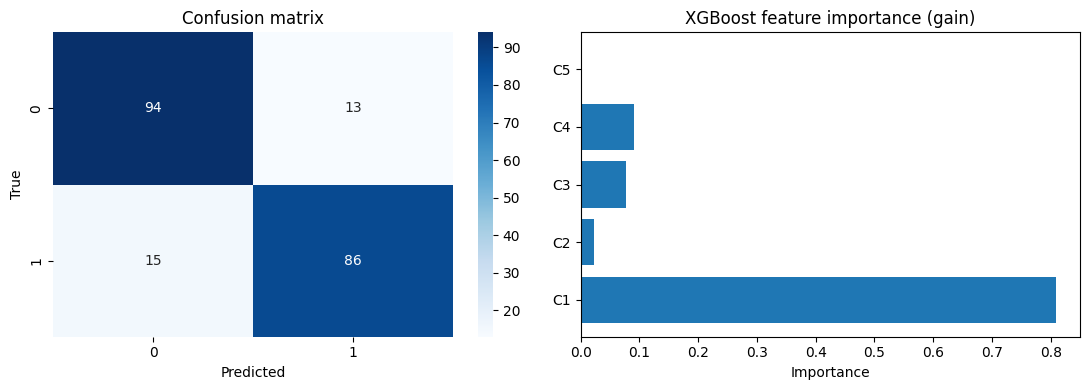

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                              classification_report, confusion_matrix)
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
import xgboost as xgb
import shap

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

def rnd(x, n=4):
    return round(float(np.asarray(x).ravel()[0]), n)

DATA_PATH = Path(r"/home/piotr/Studia/6_Semestr/DecisionAnalysis/project2/MonoData/monodata/mammographic.csv")
df = pd.read_csv(DATA_PATH, header=None)
FEATURE_NAMES = [f"C{j+1}" for j in range(df.shape[1]-1)]
NUM_CRITERIA = len(FEATURE_NAMES)
X = df.iloc[:, :-1].values.astype(np.float64)

y = (df.iloc[:, -1].values).astype(np.int32)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)

mono = tuple([1]*NUM_CRITERIA)
clf = xgb.XGBClassifier(
    n_estimators=5, max_depth=3, learning_rate=0.05,
    subsample=0.9, colsample_bytree=0.9,
    objective="binary:logistic", eval_metric="auc",
    monotone_constraints=mono, random_state=RANDOM_STATE, n_jobs=-1)
clf.fit(X_train, y_train)

p_test = clf.predict_proba(X_test)[:, 1]
y_pred = (p_test >= 0.5).astype(int)
print("Accuracy:", rnd(accuracy_score(y_test, y_pred)))
print("F1:      ", rnd(f1_score(y_test, y_pred)))
print("AUC:     ", rnd(roc_auc_score(y_test, p_test)))
print()
print(classification_report(y_test, y_pred, digits=4))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues", ax=ax[0])
ax[0].set_title("Confusion matrix"); ax[0].set_xlabel("Predicted"); ax[0].set_ylabel("True")
ax[1].barh(FEATURE_NAMES, clf.feature_importances_)
ax[1].set_title("XGBoost feature importance (gain)"); ax[1].set_xlabel("Importance")
plt.tight_layout(); plt.show()

/tmp/ipykernel_2187302/3070987776.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_vals, X_test, feature_names=FEATURE_NAMES, show=True)


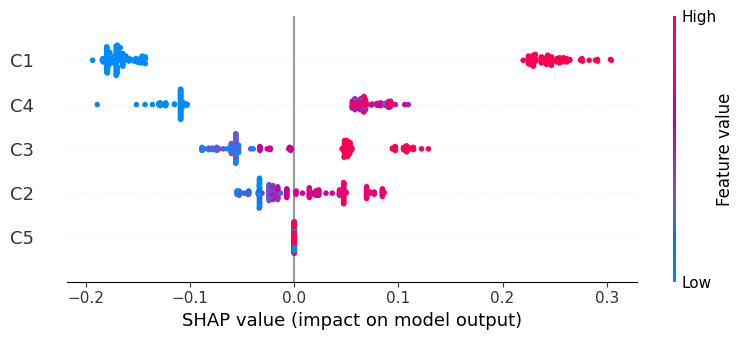

In [2]:
explainer = shap.TreeExplainer(clf)
shap_vals = explainer.shap_values(X_test)
shap.summary_plot(shap_vals, X_test, feature_names=FEATURE_NAMES, show=True)

XGBoost Tree Visualization with Graphviz
Number of trees: 5
Max depth: 3

Generating tree 0 visualization...


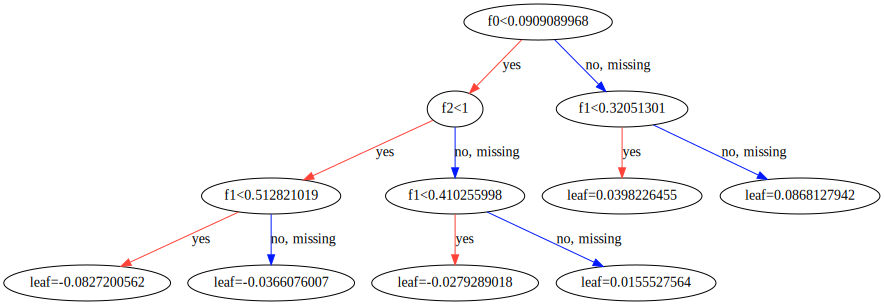

Generating tree 1 visualization...


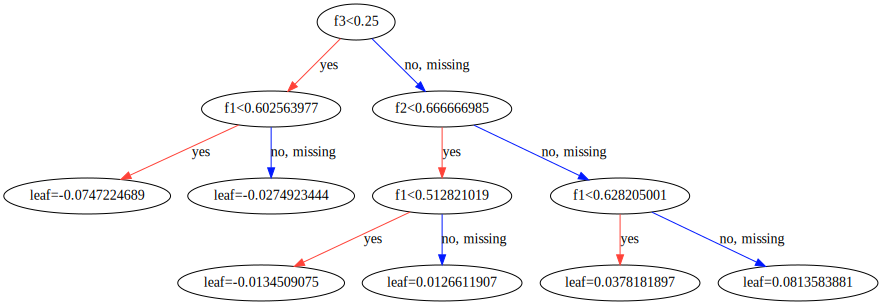

Generating tree 2 visualization...


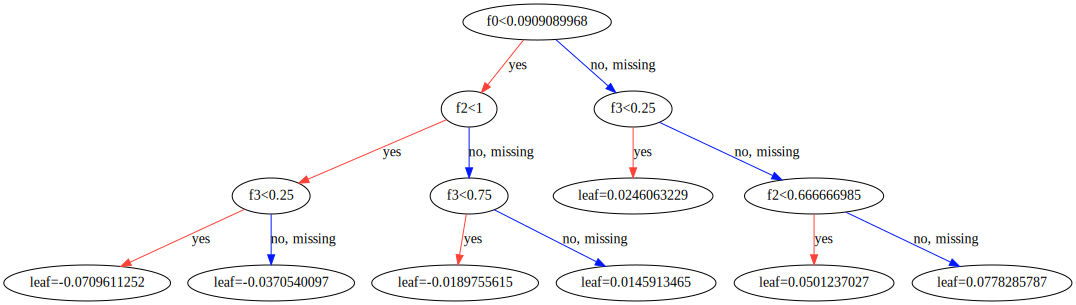

Tree Statistics
Tree 0: 11 nodes
  Root: 0:[f0<0.0909089968] yes=1,no=2,missing=2,gain=258.917389,cover=138.869...
Tree 1: 11 nodes
  Root: 0:[f3<0.25] yes=1,no=2,missing=2,gain=167.931595,cover=136.699097...
Tree 2: 13 nodes
  Root: 0:[f0<0.0909089968] yes=1,no=2,missing=2,gain=187.586319,cover=136.620...


In [3]:
from xgboost import to_graphviz

print("="*70)
print("XGBoost Tree Visualization with Graphviz")
print("="*70)
print(f"Number of trees: {clf.n_estimators}")
print(f"Max depth: {clf.max_depth}")
print()

tree_indices = [0, 1, 2]

for tree_idx in tree_indices:
    print(f"Generating tree {tree_idx} visualization...")
    
    graph = to_graphviz(
        clf.get_booster(),
        tree_idx=tree_idx,
        rankdir="TB",
        yes_color="#0119ff",
        no_color="#ff4238"
    )
    
    display(graph)
    

print("="*70)
print("Tree Statistics")
print("="*70)
trees_dump = clf.get_booster().get_dump(with_stats=True)
for i in range(min(3, len(trees_dump))):
    lines = trees_dump[i].strip().split('\n')
    print(f"Tree {i}: {len(lines)} nodes")
    root_line = lines[0][:70]
    print(f"  Root: {root_line}...")


/home/piotr/Studia/6_Semestr/DecisionAnalysis/project2/.venv/lib/python3.14/site-packages/sklearn/inspection/_plot/partial_dependence.py:990: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim([min_val, max_val])


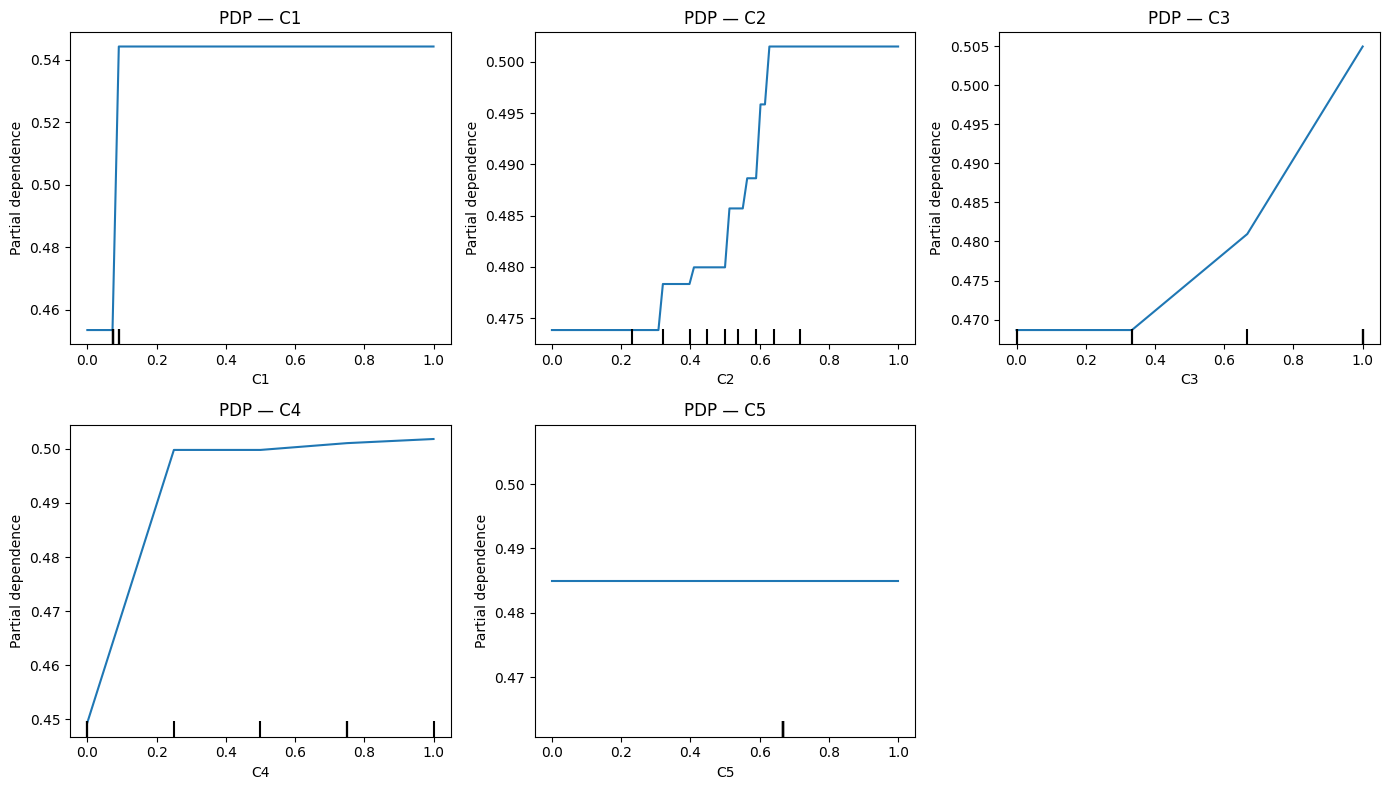

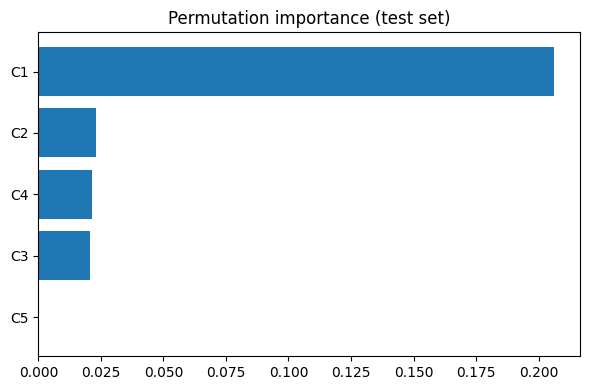

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for j in range(NUM_CRITERIA):
    ax = axes.ravel()[j]
    PartialDependenceDisplay.from_estimator(clf, X_train, features=[j],
                                             feature_names=FEATURE_NAMES, ax=ax)
    ax.set_title(f"PDP — {FEATURE_NAMES[j]}")
axes.ravel()[-1].axis("off")
plt.tight_layout(); plt.show()

# Permutation importance
pi = permutation_importance(clf, X_test, y_test, n_repeats=30,
                             random_state=RANDOM_STATE, n_jobs=-1)
order = np.argsort(pi.importances_mean)
plt.figure(figsize=(6, 4))
plt.barh(np.array(FEATURE_NAMES)[order], pi.importances_mean[order])
plt.title("Permutation importance (test set)"); 
plt.tight_layout(); 
plt.show()

* predicted probability and SHAP local explanation
* **analytical** single-criterion minimal change to flip the class
* **sampling** verification (Gaussian perturbations on one criterion at a time)
* ICE-style curve for one criterion

=== Alternative 0 (test idx 4)  P(class1)=0.3942  true=0 ===
  SHAP C1 = -0.1795
  SHAP C2 = -0.0206
  SHAP C3 = -0.0604
  SHAP C4 = -0.1092
  SHAP C5 = 0.0

  C1: analytical delta = 0.0182
  C2: no crossing to p=0.5 in [0,1]
  C3: no crossing to p=0.5 in [0,1]
  C4: no crossing to p=0.5 in [0,1]
  C5: no crossing to p=0.5 in [0,1]
  Sampling: smallest flip on C1, delta=0.0182 (356 flips total)

=== Alternative 1 (test idx 64)  P(class1)=0.4924  true=1 ===
  SHAP C1 = 0.2198
  SHAP C2 = -0.0482
  SHAP C3 = 0.0472
  SHAP C4 = -0.1892
  SHAP C5 = 0.0

  C1: no crossing to p=0.5 in [0,1]
  C2: analytical delta = 0.0385
  C3: no crossing to p=0.5 in [0,1]
  C4: analytical delta = 0.25
  C5: no crossing to p=0.5 in [0,1]
  Sampling: smallest flip on C2, delta=0.0385 (230 flips total)

=== Alternative 2 (test idx 200)  P(class1)=0.5823  true=1 ===
  SHAP C1 = 0.2373
  SHAP C2 = 0.0475
  SHAP C3 = 0.0487
  SHAP C4 = 0.0585
  SHAP C5 = 0.0

  C1: no crossing to p=0.5 in [0,1]
  C2: no crossing

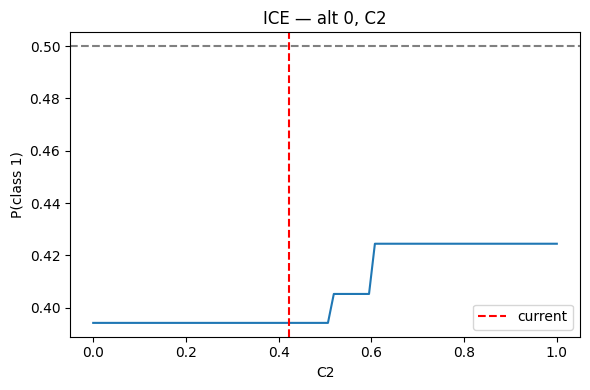

In [ ]:
def predict_p(xrow):
    return float(clf.predict_proba(xrow.reshape(1,-1))[0,1])

def bisect_delta(j, xrow, target=0.5):
    def p_at(v):
        z = xrow.copy(); z[j] = v
        return predict_p(z)
    lo, hi = 0.0, 1.0
    flo, fhi = p_at(lo)-target, p_at(hi)-target
    if flo*fhi > 0:
        return np.nan
    for _ in range(64):
        mid = 0.5*(lo+hi); fm = p_at(mid)-target
        if flo*fm <= 0: hi = mid; fhi = fm
        else:           lo = mid; flo = fm
    return 0.5*(lo+hi) - float(xrow[j])

order_p = np.argsort(p_test)
sel = [order_p[0], order_p[len(order_p)//2], order_p[-1]]

for k, ridx in enumerate(sel):
    xrow = X_test[ridx].copy()
    p0 = predict_p(xrow)
    print(f"=== Alternative {k} (test idx {ridx})  P(class1)={rnd(p0)}  true={int(y_test[ridx])} ===")
    sv = explainer.shap_values(xrow.reshape(1,-1))[0]
    for fn, s in zip(FEATURE_NAMES, sv):
        print(f"  SHAP {fn} = {rnd(float(s))}")
    print()
    for j in range(NUM_CRITERIA):
        d = bisect_delta(j, xrow)
        if np.isnan(d):
            print(f"  {FEATURE_NAMES[j]}: no crossing to p=0.5 in [0,1]")
        else:
            print(f"  {FEATURE_NAMES[j]}: analytical delta = {rnd(d)}")

    np.random.seed(RANDOM_STATE + k)
    flips = []
    for _ in range(5000):
        z = xrow.copy(); jj = np.random.randint(NUM_CRITERIA)
        z[jj] = np.clip(z[jj]+np.random.normal(0,0.05), 0, 1)
        if (predict_p(z)>=0.5) != (p0>=0.5):
            flips.append((jj, float(z[jj]-xrow[jj])))
    if flips:
        bj, bd = min(flips, key=lambda t: abs(t[1]))
        print(f"  Sampling: smallest flip on {FEATURE_NAMES[bj]}, delta={rnd(bd)} ({len(flips)} flips total)")
    else:
        print("  Sampling: no flip found")
    print()

x0 = X_test[sel[0]].copy(); feat = 1
grid = np.linspace(0, 1, 80)
ice = [predict_p(np.where(np.arange(NUM_CRITERIA)==feat, v, x0)) for v in grid]
plt.figure(figsize=(6,4))
plt.plot(grid, ice)
plt.axhline(0.5, color="gray", ls="--"); plt.axvline(x0[feat], color="red", ls="--", label="current")
plt.xlabel(FEATURE_NAMES[feat]); plt.ylabel("P(class 1)")
plt.title(f"ICE — alt 0, {FEATURE_NAMES[feat]}"); plt.legend(); plt.tight_layout(); plt.show()

## Summary XGBoost:
- looking at everything, we can see that C1 is the most important critetria when it comes to making our decision
- in Permutation Importance after permutating C1 we increased the error the most
- Also in the Shap Value plot we can see that C1 affects the resoult the most (in both the high and low values of it), the second most impactfull here looks to be C4 (though mostly the lower values of C4)
- PDP shows that C5 doesn't impact the prediction
- For the 3 alternatives, 

# Step 2 — ANN-UTADIS (Interpretable neural MCDA)

In [ ]:
import sys
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                              classification_report, confusion_matrix)
from sklearn.inspection import permutation_importance
from sklearn.base import BaseEstimator, ClassifierMixin
import torch

LAB = r"/home/piotr/Studia/6_Semestr/DecisionAnalysis/project2/lab"
sys.path.insert(0, LAB)
from utils import (Hook, append_output, get_simple_input,
                   CreateDataLoader, AUC,
                     Train)
from uta import Uta
from norm_layer import NormLayer

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

def rnd(x, n=4):
    return round(float(np.asarray(x).ravel()[0]), n)

DATA_PATH = Path(r"/home/piotr/Studia/6_Semestr/DecisionAnalysis/project2/MonoData/monodata/mammographic.csv")
df = pd.read_csv(DATA_PATH, header=None)
FEATURE_NAMES = [f"C{j+1}" for j in range(df.shape[1]-1)]
NUM_CRITERIA = len(FEATURE_NAMES)

X_all = df.iloc[:, :NUM_CRITERIA].values.astype(np.float64)
y_all = (df.iloc[:, -1].values > 0).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.25, stratify=y_all, random_state=RANDOM_STATE)

X_train_3d = X_train.reshape(-1, 1, NUM_CRITERIA)
X_test_3d  = X_test.reshape(-1, 1, NUM_CRITERIA)

train_dl = CreateDataLoader(X_train_3d, y_train)
test_dl  = CreateDataLoader(X_test_3d,  y_test)

CKPT_PATH = "ann_utadis.pt"
NUM_HIDDEN = 30
uta = Uta(NUM_CRITERIA, NUM_HIDDEN)
model = NormLayer(uta, NUM_CRITERIA)

best_acc, best_auc, stats_train, stats_test = Train(
    model, train_dl, test_dl, CKPT_PATH,
    epoch_nr=300, lr=0.001, slope_decrease=True)

print(f"Best train acc: {rnd(best_acc)}   Best train AUC: {rnd(best_auc)}")

100%|██████████| 300/300 [00:02<00:00, 132.51it/s]

Best train acc: 0.8357   Best train AUC: 0.8936


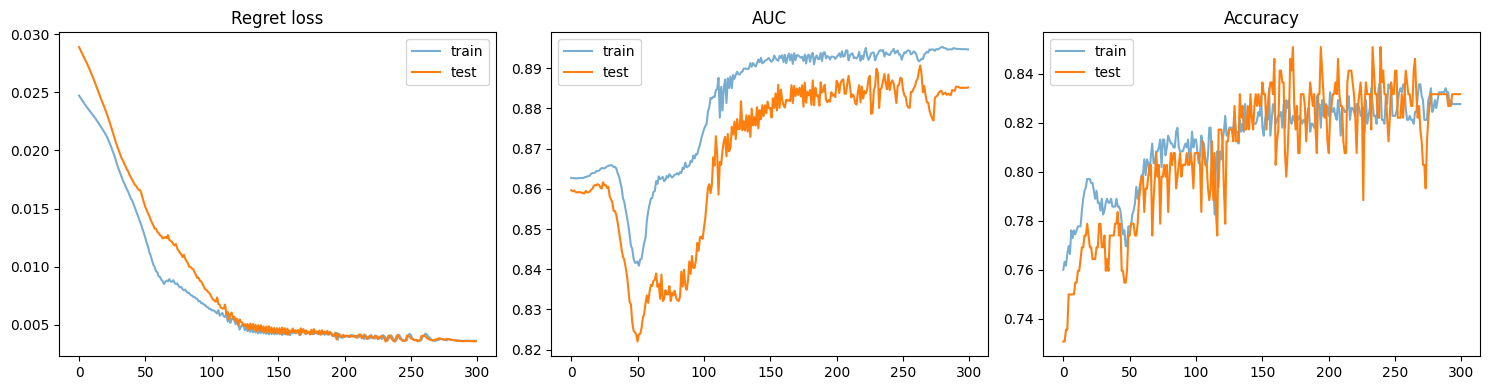

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot([l.item() if hasattr(l,'item') else l for l in stats_train.losses], label="train", alpha=0.6)
axes[0].plot([l if isinstance(l, float) else l for l in stats_test.losses], label="test")
axes[0].set_title("Regret loss"); axes[0].legend()
axes[1].plot(stats_train.auc_scores, label="train", alpha=0.6)
axes[1].plot(stats_test.auc_scores, label="test"); axes[1].set_title("AUC"); axes[1].legend()
axes[2].plot(stats_train.acc_scores, label="train", alpha=0.6)
axes[2].plot(stats_test.acc_scores, label="test"); axes[2].set_title("Accuracy"); axes[2].legend()
plt.tight_layout(); plt.show()

Accuracy: 0.8317
F1:       0.8223
AUC:      0.8843

              precision    recall  f1-score   support

           0     0.8214    0.8598    0.8402       107
           1     0.8438    0.8020    0.8223       101

    accuracy                         0.8317       208
   macro avg     0.8326    0.8309    0.8313       208
weighted avg     0.8323    0.8317    0.8315       208



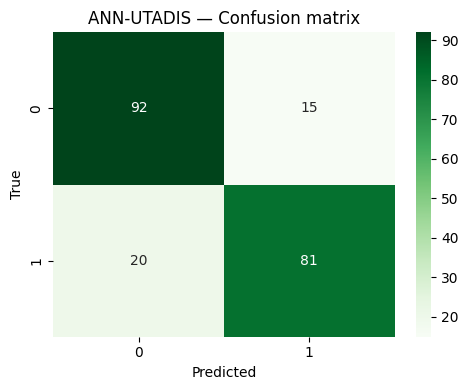

In [22]:
ckpt = torch.load(CKPT_PATH, weights_only=False)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

with torch.no_grad():
    X_t = torch.tensor(X_test_3d, dtype=torch.float32)
    outputs = model(X_t).squeeze()
    y_pred = (outputs > 0).int().numpy()
    scores = outputs.numpy()

acc = rnd(accuracy_score(y_test, y_pred))
f1  = rnd(f1_score(y_test, y_pred))
auc_val = rnd(roc_auc_score(y_test, scores))
print("Accuracy:", acc); print("F1:      ", f1); print("AUC:     ", auc_val)
print()
print(classification_report(y_test, y_pred, digits=4))

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Greens", ax=ax)
ax.set_title("ANN-UTADIS — Confusion matrix"); ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.tight_layout(); plt.show()

## Marginal value functions

We use the lab's Hook mechanism: attach a forward hook to the monotonic layer,
sweep a common performance level from 0 to 1 across all criteria, and record the
per-criterion marginal output.

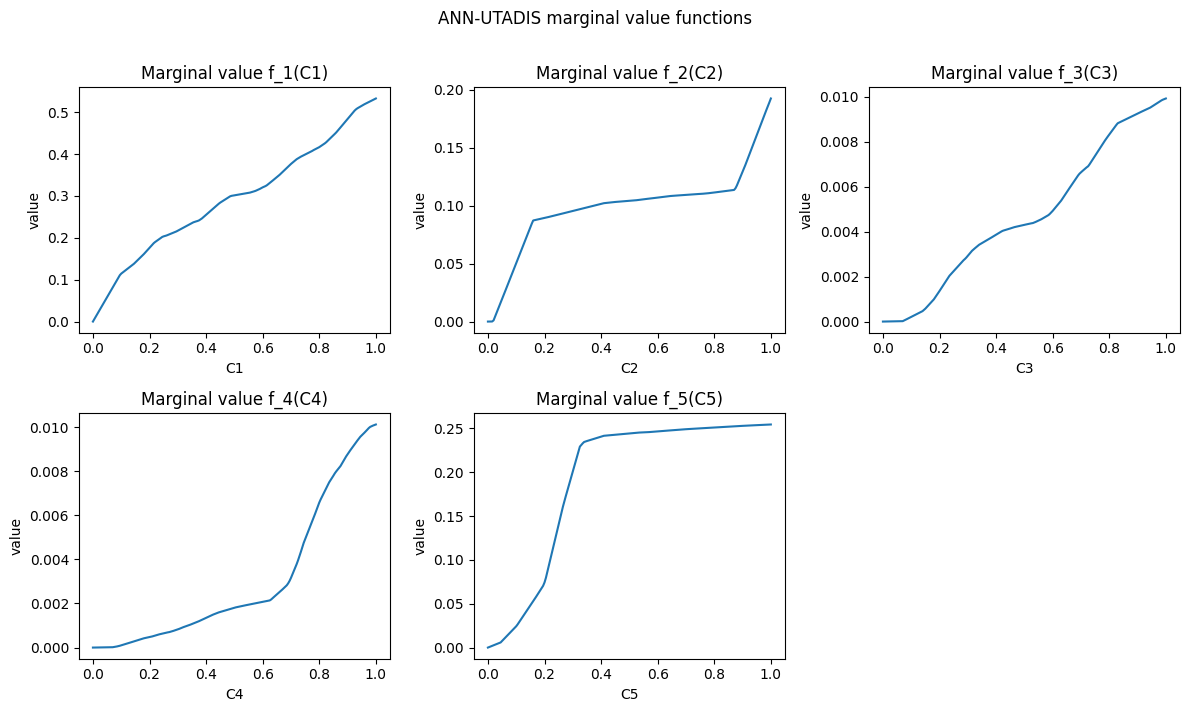

In [10]:
hook = Hook(model.method_instance.monotonic_layer, append_output)
hook.stats = []

n_pts = 200
with torch.no_grad():
    for i in range(n_pts + 1):
        v = i / n_pts
        inp = get_simple_input(v, NUM_CRITERIA)
        _ = model(inp)

outs = torch.stack(hook.stats[::3]) 
baseline = outs[0]
outs = outs - baseline
total_range = outs[-1].sum()
if total_range.abs() > 1e-8:
    outs = outs / total_range

xs = np.linspace(0, 1, outs.shape[0])

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for j in range(NUM_CRITERIA):
    ax = axes.ravel()[j]
    vals = outs[:, 0, j].numpy()
    ax.plot(xs, vals)
    ax.set_title(f"Marginal value f_{j+1}({FEATURE_NAMES[j]})")
    ax.set_xlabel(FEATURE_NAMES[j]); ax.set_ylabel("value")
axes.ravel()[-1].axis("off")
plt.suptitle("ANN-UTADIS marginal value functions", y=1.01)
plt.tight_layout(); plt.show()
hook.remove()

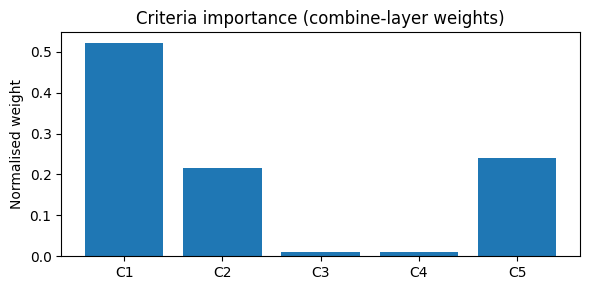

Criteria weights: {'C1': 0.5215, 'C2': 0.2168, 'C3': 0.0112, 'C4': 0.0101, 'C5': 0.2404}


In [11]:
combine_w = model.method_instance.monotonic_layer.criterion_layer_combine.weight.data.clone()
combine_w[combine_w < 0] = 0
crit_importance = combine_w.sum(0).numpy()
crit_importance = crit_importance / crit_importance.sum()

plt.figure(figsize=(6, 3))
plt.bar(FEATURE_NAMES, crit_importance)
plt.title("Criteria importance (combine-layer weights)")
plt.ylabel("Normalised weight"); plt.tight_layout(); plt.show()
print("Criteria weights:", {fn: rnd(w) for fn, w in zip(FEATURE_NAMES, crit_importance)})

## 2.1 — Explanation of 3 alternatives

For ANN-UTADIS the model is additive + normalised + thresholded. The decision boundary
is: normalised utility = threshold (learned parameter). We can analytically bisect along
each criterion to find the minimal single-feature change that flips the class.

In [ ]:
def model_score(xrow):
    "Return raw model output (utility - threshold) for a 1-D numpy vector."
    xt = torch.tensor(xrow.reshape(1, 1, NUM_CRITERIA), dtype=torch.float32)
    with torch.no_grad():
        return float(model(xt).item())

def model_prob(xrow):
    "Pseudo-probability: sigmoid of model score."
    s = model_score(xrow)
    return float(1/(1+np.exp(-s*5)))  # scaled sigmoid for visualisation

def bisect_utadis(j, xrow):
    lo, hi = 0.0, 1.0
    def f(v):
        z = xrow.copy(); z[j] = v
        return model_score(z)
    flo, fhi = f(lo), f(hi)
    if flo * fhi > 0:
        return np.nan
    for _ in range(64):
        mid = 0.5*(lo+hi); fm = f(mid)
        if flo*fm <= 0: hi = mid
        else:           lo = mid; flo = fm
    return 0.5*(lo+hi) - float(xrow[j])

all_scores = np.array([model_score(X_test[i]) for i in range(len(X_test))])
order_s = np.argsort(all_scores)
sel = [order_s[0], order_s[len(order_s)//2], order_s[-1]]

for k, ridx in enumerate(sel):
    xrow = X_test[ridx].copy()
    sc = model_score(xrow)
    pred = 1 if sc > 0 else 0
    print(f"=== Alt {k}  score={rnd(sc)}  pred={pred}  true={int(y_test[ridx])} ===")
    for j in range(NUM_CRITERIA):
        d = bisect_utadis(j, xrow)
        if np.isnan(d):
            print(f"  {FEATURE_NAMES[j]}: no crossing in [0,1]")
        else:
            print(f"  {FEATURE_NAMES[j]}: analytical delta = {rnd(d)}")
    np.random.seed(RANDOM_STATE + k)
    flips = []
    for _ in range(5000):
        z = xrow.copy(); jj = np.random.randint(NUM_CRITERIA)
        z[jj] = np.clip(z[jj]+np.random.normal(0, 0.05), 0, 1)
        if (model_score(z) > 0) != (sc > 0):
            flips.append((jj, float(z[jj]-xrow[jj])))
    if flips:
        bj, bd = min(flips, key=lambda t: abs(t[1]))
        print(f"  Sampling: smallest flip on {FEATURE_NAMES[bj]}, delta={rnd(bd)}")
    else:
        print("  Sampling: no flip")

x0 = torch.tensor(X_test[sel[0]].reshape(1,1,NUM_CRITERIA), requires_grad=True, dtype=torch.float32)
out = model(x0).sum()
out.backward()
grads = x0.grad.numpy().ravel()
print(f"\nGradient at alt 0: {[rnd(float(g)) for g in grads]}")

=== Alt 0  score=-0.2697  pred=0  true=0 ===
  C1: analytical delta = 0.593
  C2: no crossing in [0,1]
  C3: no crossing in [0,1]
  C4: no crossing in [0,1]
  C5: no crossing in [0,1]
  Sampling: no flip
=== Alt 1  score=-0.0049  pred=0  true=0 ===
  C1: analytical delta = 0.0042
  C2: analytical delta = 0.1189
  C3: analytical delta = 0.463
  C4: analytical delta = 0.305
  C5: analytical delta = 0.2518
  Sampling: smallest flip on C1, delta=0.0043
=== Alt 2  score=0.0454  pred=1  true=1 ===
  C1: analytical delta = -0.0457
  C2: analytical delta = -0.67
  C3: no crossing in [0,1]
  C4: no crossing in [0,1]
  C5: analytical delta = -0.365
  Sampling: smallest flip on C1, delta=-0.0458

Gradient at alt 0: [1.1647, 0.0617, 0.0002, 0.0002, 0.1278]


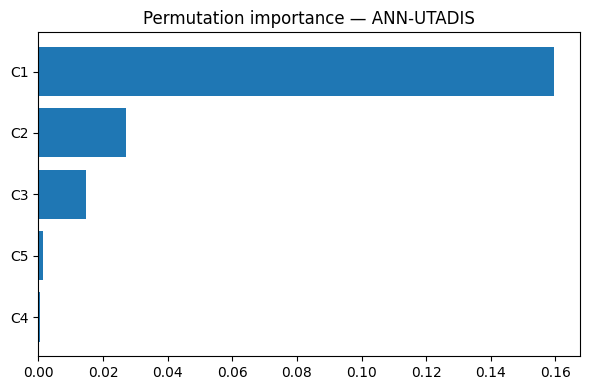

In [23]:
class SKWrapper(BaseEstimator, ClassifierMixin):
    def fit(self, X, y):
        self.fitted_ = True
        self.classes_ = np.unique(y)
        self.n_features_in_ = X.shape[1]
        return self
    def predict(self, X):
        return np.array([1 if model_score(X[i]) > 0 else 0 for i in range(len(X))])

sk = SKWrapper().fit(X_train, y_train)
pi = permutation_importance(sk, X_test, y_test, n_repeats=20, random_state=RANDOM_STATE)
order = np.argsort(pi.importances_mean)
plt.figure(figsize=(6, 4))
plt.barh(np.array(FEATURE_NAMES)[order], pi.importances_mean[order])
plt.title("Permutation importance — ANN-UTADIS"); plt.tight_layout(); plt.show()

## Summary - ANN-UTADIS
- Again we can see through the Permutation importance, and Critetia Importance and the marginal plots C1 looks to be the most important
- For ANN-UtaDis C3 and C4 look to have quite small impact on the final resoult (looking and y axis of Marginal Value plots and Criteria Importance)

# Neural network (multi-layer, nonlinear activations)

Accuracy: 0.8221
F1:       0.8213
AUC:      0.8981

              precision    recall  f1-score   support

         0.0     0.8431    0.8037    0.8230       107
         1.0     0.8019    0.8416    0.8213       101

    accuracy                         0.8221       208
   macro avg     0.8225    0.8227    0.8221       208
weighted avg     0.8231    0.8221    0.8221       208



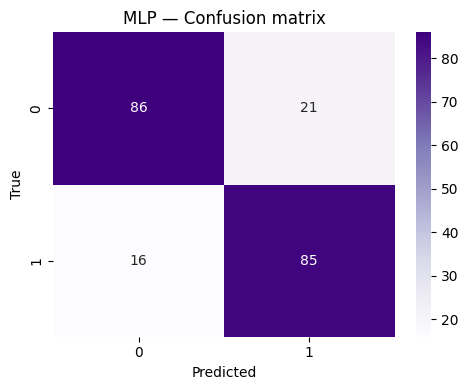

In [25]:
import warnings, sys
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                              classification_report, confusion_matrix)
from sklearn.inspection import permutation_importance
from sklearn.base import BaseEstimator, ClassifierMixin
import shap

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE); torch.manual_seed(RANDOM_STATE)

def rnd(x, n=4):
    return round(float(np.asarray(x).ravel()[0]), n)

DATA_PATH = Path(r"/home/piotr/Studia/6_Semestr/DecisionAnalysis/project2/MonoData/monodata/mammographic.csv")
df = pd.read_csv(DATA_PATH, header=None)
FEATURE_NAMES = [f"C{j+1}" for j in range(df.shape[1]-1)]
NUM_CRITERIA = len(FEATURE_NAMES)
X = df.iloc[:, :-1].values.astype(np.float32)
y = (df.iloc[:, -1].values > 0).astype(np.float32)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)

class MLP(nn.Module):
    def __init__(self, n_in):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_in, 64), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, 32),   nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(32, 1))
    def forward(self, x):
        return self.net(x)

mlp = MLP(NUM_CRITERIA)
ds = TensorDataset(torch.tensor(X_train), torch.tensor(y_train))
dl = DataLoader(ds, batch_size=64, shuffle=True)
opt = optim.AdamW(mlp.parameters(), lr=0.01)
loss_fn = nn.BCEWithLogitsLoss()

mlp.train()
for ep in range(350):
    for xb, yb in dl:
        opt.zero_grad()
        loss = loss_fn(mlp(xb).squeeze(-1), yb)
        loss.backward(); opt.step()
mlp.eval()

@torch.no_grad()
def pred_proba(Xv):
    logit = mlp(torch.tensor(Xv, dtype=torch.float32)).squeeze(-1).numpy()
    return 1/(1+np.exp(-logit))

p_test = pred_proba(X_test)
y_pred = (p_test >= 0.5).astype(int)
print("Accuracy:", rnd(accuracy_score(y_test, y_pred)))
print("F1:      ", rnd(f1_score(y_test, y_pred)))
print("AUC:     ", rnd(roc_auc_score(y_test, p_test)))
print()
print(classification_report(y_test, y_pred, digits=4))

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Purples", ax=ax)
ax.set_title("MLP — Confusion matrix"); ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.tight_layout(); plt.show()

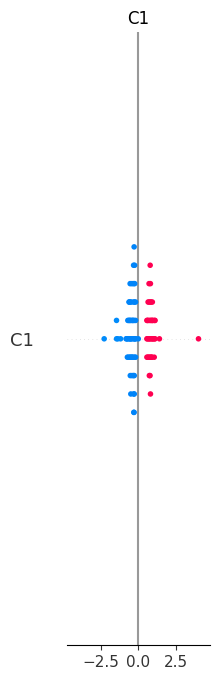

In [ ]:
bg = torch.tensor(X_train[:200], dtype=torch.float32)
explainer = shap.DeepExplainer(mlp, bg)
sv = explainer.shap_values(torch.tensor(X_test[:100], dtype=torch.float32))
shap.summary_plot(sv, X_test[:100], feature_names=FEATURE_NAMES, show=True)

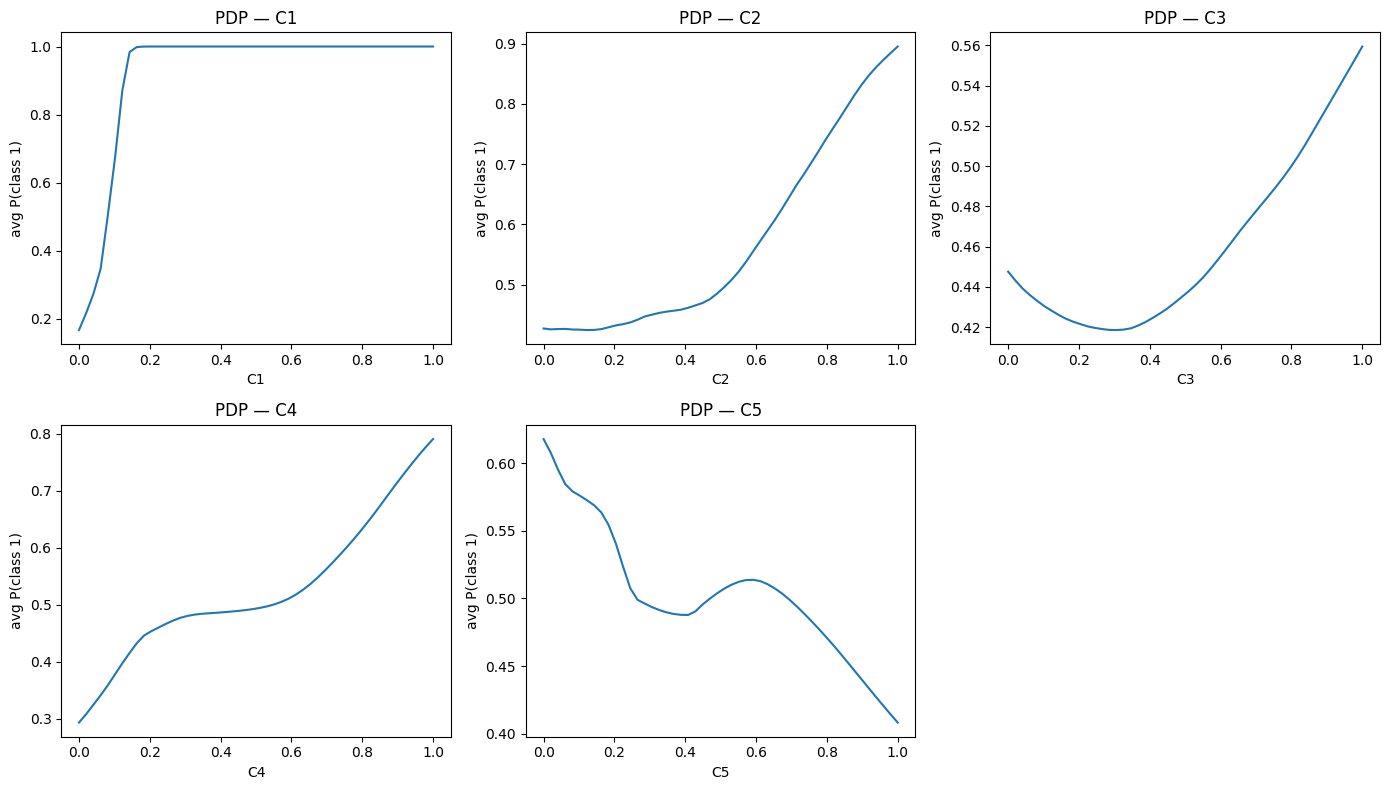

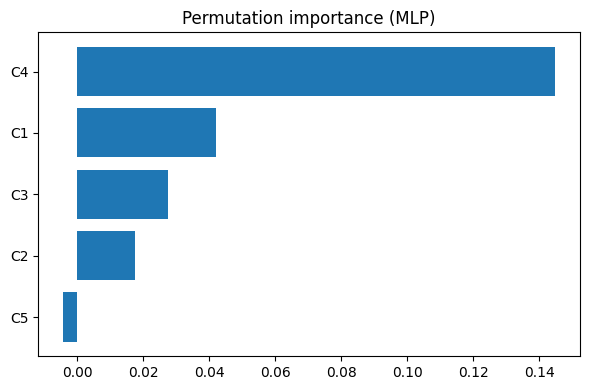

In [ ]:
# Manual PDP for all criteria
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
grid = np.linspace(0, 1, 50)
for j in range(NUM_CRITERIA):
    avg = []
    for v in grid:
        Xb = X_train.copy(); Xb[:, j] = v
        avg.append(float(pred_proba(Xb).mean()))
    ax = axes.ravel()[j]
    ax.plot(grid, avg); ax.set_xlabel(FEATURE_NAMES[j]); ax.set_ylabel("avg P(class 1)")
    ax.set_title(f"PDP — {FEATURE_NAMES[j]}")
axes.ravel()[-1].axis("off")
plt.tight_layout(); plt.show()

class TorchWrap(BaseEstimator, ClassifierMixin):
    def fit(self, X, y):
        self.fitted_ = True; self.classes_ = np.unique(y); self.n_features_in_ = X.shape[1]
        return self
    def predict(self, X): return (pred_proba(X)>=0.5).astype(int)
tw = TorchWrap().fit(X_train, y_train)
pi = permutation_importance(tw, X_test, y_test, n_repeats=25, random_state=RANDOM_STATE)
order = np.argsort(pi.importances_mean)
plt.figure(figsize=(6, 4))
plt.barh(np.array(FEATURE_NAMES)[order], pi.importances_mean[order])
plt.title("Permutation importance (MLP)"); plt.tight_layout(); plt.show()

## 2.1 — Explanation of 3 alternatives

=== Alt 0  P=0.0  true=0 ===
  C1: delta = 0.0665
  C2: delta = 0.6896
  C3: delta = no crossing
  C4: delta = 0.6959
  C5: delta = -0.6662
  Sampling: smallest flip on C1, delta=0.0671

=== Alt 1  P=0.5365  true=1 ===
  C1: delta = -0.0041
  C2: delta = no crossing
  C3: delta = -0.0704
  C4: delta = -0.2233
  C5: delta = no crossing
  Sampling: smallest flip on C1, delta=-0.0043

=== Alt 2  P=0.9834  true=1 ===
  C1: delta = -0.1062
  C2: delta = no crossing
  C3: delta = no crossing
  C4: delta = no crossing
  C5: delta = no crossing
  Sampling: smallest flip on C1, delta=-0.1081



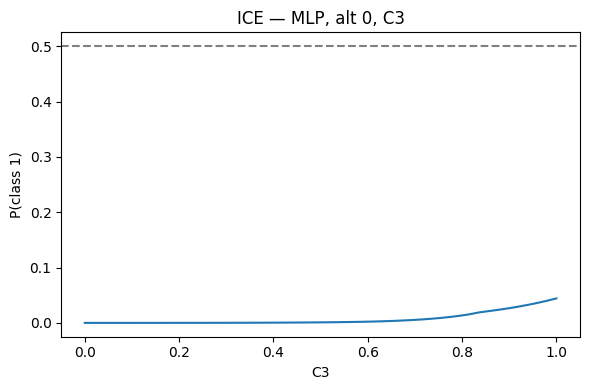

In [27]:
def p_row(x):
    return float(pred_proba(x.reshape(1,-1))[0])

def bisect_mlp(j, xrow):
    lo, hi = 0.0, 1.0
    def logit_at(v):
        z = xrow.copy(); z[j] = v; pv = p_row(z)
        return np.log(pv/(1-pv+1e-12))
    flo, fhi = logit_at(lo), logit_at(hi)
    if flo*fhi > 0: return np.nan
    for _ in range(64):
        mid = 0.5*(lo+hi); fm = logit_at(mid)
        if flo*fm <= 0: hi = mid
        else: lo = mid; flo = fm
    return 0.5*(lo+hi) - float(xrow[j])

order_p = np.argsort(p_test)
sel = [order_p[0], order_p[len(order_p)//2], order_p[-1]]

for k, ridx in enumerate(sel):
    xrow = X_test[ridx].copy()
    p0 = p_row(xrow)
    print(f"=== Alt {k}  P={rnd(p0)}  true={int(y_test[ridx])} ===")
    for j in range(NUM_CRITERIA):
        d = bisect_mlp(j, xrow)
        s = "no crossing" if np.isnan(d) else str(rnd(d))
        print(f"  {FEATURE_NAMES[j]}: delta = {s}")
    np.random.seed(1+k)
    flips = []
    for _ in range(5000):
        z = xrow.copy(); jj = np.random.randint(NUM_CRITERIA)
        z[jj] = np.clip(z[jj]+np.random.normal(0,0.05), 0, 1)
        if (p_row(z)>=0.5) != (p0>=0.5):
            flips.append((jj, float(z[jj]-xrow[jj])))
    if flips:
        bj, bd = min(flips, key=lambda t: abs(t[1]))
        print(f"  Sampling: smallest flip on {FEATURE_NAMES[bj]}, delta={rnd(bd)}")
    else:
        print("  No sampling flip")
    print()

x0 = X_test[sel[0]].copy(); feat = 2
ice = [p_row(np.where(np.arange(NUM_CRITERIA)==feat, v, x0).astype(np.float32)) for v in grid]
plt.figure(figsize=(6,4))
plt.plot(grid, ice); plt.axhline(0.5, color="gray", ls="--")
plt.xlabel(FEATURE_NAMES[feat]); plt.ylabel("P(class 1)")
plt.title(f"ICE — MLP, alt 0, {FEATURE_NAMES[feat]}"); plt.tight_layout(); plt.show()

## 2.2 — Interpretation

- unlike XGBoost and ANN-UTADIS, the MLP has no monotonicity constraint. The learned relationship may violate domain monotonicity in some regions.

- The MLP achieves competitive AUC but offers no structural interpretability. Explanations rely entirely on post-hoc tools (SHAP, PDP, permutation importance) rather than transparent model parameters.

- Still using the Permutation see that C4 and C1 are the most important, whereas C5 is not.

- Looking at PDP , C1 has a sharp increase at one point and is almost indifferent in the rest of domain.